# 🔧 0. Setup & Instalasi

In [ ]:
# Install dependencies
import subprocess, sys
pkgs = ["shap", "nbformat"]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"])

import warnings; warnings.filterwarnings('ignore')
print("Setup selesai.")


Setup selesai.


# Analisis Komparatif Regresi Harga RAM (CRISP-DM)

## 1. Business Understanding

**Masalah:** Industri perangkat keras rentan terhadap fluktuasi harga memori (RAM) akibat krisis pasokan, pergantian generasi, dan dinamika pasar global.

**Tujuan Prediksi:** Memprediksi harga RAM (`price_usd`) berdasarkan spesifikasi teknis dan kondisi pasar menggunakan tiga algoritma regresi, masing-masing diuji dalam kondisi *default* dan *tuned* (sebelum dan sesudah hyperparameter tuning):
- **Linear Regression** → Default (tanpa tuning) vs. Tuned (Ridge + PolynomialFeatures derajat 2 + Log-Transform target)
- **K-Nearest Neighbors (KNN)** → Default (k=5) vs. Tuned (RandomizedSearchCV: `n_neighbors`, `weights`, `p`, `metric`)
- **Support Vector Regressor (SVR)** → Default vs. Tuned (Log-Transform target + RandomizedSearchCV: `C`, `gamma`, `kernel`, `epsilon`)

**Manfaat:** Membantu distributor, integrator sistem, dan produsen dalam:
- Perencanaan pengadaan & manajemen inventori
- Strategi penetapan harga kompetitif
- Antisipasi fluktuasi harga berdasarkan spesifikasi teknis


## 2. Data Understanding

Dataset yang digunakan adalah **Ultimate Memory Shortage Crisis** — dataset sintetis yang merepresentasikan kondisi pasar RAM global.

**Informasi Dataset:**
- **Jumlah baris:** 10.000 entri produk RAM
- **Jumlah kolom:** 28 kolom (sebelum preprocessing)
- **Target variable:** `price_usd` (harga dalam USD)
- **Rentang harga:** dari puluhan USD (RAM Consumer biasa) hingga puluhan ribu USD (Enterprise/AI RAM)

**Kolom Utama:**

| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `kit_id` | Object | ID unik produk |
| `brand`, `model_name` | Object | Merek & model RAM |
| `timestamp` | Datetime | Tanggal transaksi/listing |
| `region` | Object | Wilayah pasar (North America, EMEA, dll.) |
| `generation` | Object | Generasi DDR (DDR4, DDR5, DDR6 Preview) |
| `form_factor` | Object | DIMM, SODIMM, LRDIMM |
| `capacity_gb` | Float | Kapasitas total dalam GB |
| `module_count` | Int | Jumlah modul |
| `is_ecc` | Bool | Error Correction Code (True/False) |
| `speed_mts` | Int | Kecepatan MT/s |
| `cas_latency` | Int | CAS Latency (timing utama) |
| `market_segment` | Object | Consumer / Enterprise/AI |
| `price_usd` | Float | **Target** — Harga dalam USD |
| `price_per_gb`, `bandwidth_per_dollar`, dll. | Float | **Akan dihapus** (data leakage!) |


Sumber Dataset: https://www.kaggle.com/datasets/moaz1911/ultimate-memory-crisis-hardware-market-dynamics/data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("Ultimate_Memory_Shortage_Crisis.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (10000, 28)


,kit_id,brand,model_name,timestamp,region,generation,form_factor,capacity_gb,module_count,is_ecc,...,latency_value_index,speed_premium_ratio,price_per_gb,price_usd,market_segment,recommended_usage,price_status,global_inventory_weeks,fab_utilization_rate,gpu_hbm_trend_gb
0,MPN-000000,Mushkin,Mushkin DDR5 6400MT/s,2026-05-13,EMEA,DDR5,DIMM,512,2,False,...,415610.03,8.8352,61.85,31665.53,Enterprise/AI,AI / Data Science,Shortage-Inflated,5.98,0.8543,236.85
1,MPN-000001,Patriot,Patriot DDR6 (Preview) 16000MT/s,2025-09-15,Greater China,DDR6 (Preview),DIMM,32,4,False,...,32041.53,3.4058,95.36,3051.57,Consumer,Gaming (AAA),Shortage-Inflated,7.82,0.7558,182.11
2,MPN-000002,Lexar,Lexar DDR6 (Preview) 12800MT/s,2024-08-27,Latin America,DDR6 (Preview),DIMM,128,2,False,...,66116.65,1.9678,55.10,7052.44,Enterprise/AI,AI / Data Science,Normal,12.18,0.5981,94.52
3,MPN-000003,Lexar,Lexar DDR4 4400MT/s,2024-09-30,EMEA,DDR4,DIMM,128,1,False,...,6188.60,1.9553,6.26,800.88,Enterprise/AI,AI / Data Science,Normal,12.64,0.6121,102.27
4,MPN-000004,Lexar,Lexar DDR5 5600MT/s,2026-07-12,EMEA,DDR5,SODIMM,48,2,False,...,19395.30,5.0509,35.36,1697.09,Consumer,Content Creation,Shortage-Inflated,5.35,0.8790,250.54


In [ ]:
print("=== INFO ===")
df.info()


=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   kit_id                  10000 non-null  object 
 1   brand                   10000 non-null  object 
 2   model_name              10000 non-null  object 
 3   timestamp               10000 non-null  object 
 4   region                  10000 non-null  object 
 5   generation              10000 non-null  object 
 6   form_factor             10000 non-null  object 
 7   capacity_gb             10000 non-null  int64  
 8   module_count            10000 non-null  int64  
 9   is_ecc                  10000 non-null  bool   
 10  speed_mts               10000 non-null  int64  
 11  cas_latency             10000 non-null  int64  
 12  voltage                 10000 non-null  float64
 13  timing_string           10000 non-null  object 
 14  die_manufacturer        10

In [ ]:
print("=== DESCRIBE ===")
df.describe()


=== DESCRIBE ===


,capacity_gb,module_count,speed_mts,cas_latency,voltage,true_latency_ns,bandwidth_per_dollar,latency_value_index,speed_premium_ratio,price_per_gb,price_usd,global_inventory_weeks,fab_utilization_rate,gpu_hbm_trend_gb
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,122.065600,2.540900,6212.941300,32.283700,1.308840,11.019142,85.039791,49676.58634,4.421987,31.749948,4656.477631,9.034998,0.723632,164.240139
std,132.709958,1.561785,2985.474922,12.108141,0.118251,2.708130,149.494946,82860.28568,2.848333,34.253978,7741.293966,3.495701,0.129758,72.087467
min,8.000000,1.000000,2133.000000,14.000000,1.000000,5.714300,1.004500,161.43000,0.960200,3.090000,24.750000,2.000000,0.500000,40.000000
25%,32.000000,2.000000,4400.000000,22.000000,1.250000,9.000000,9.310775,4973.47750,1.947975,12.910000,439.762500,6.030000,0.612400,102.442500
50%,64.000000,2.000000,6000.000000,32.000000,1.350000,10.625000,27.596000,18083.50500,3.788300,21.225000,1702.215000,9.065000,0.721900,163.290000
75%,128.000000,2.000000,7600.000000,38.000000,1.400000,12.666700,88.404025,56853.13000,6.316825,41.670000,5433.572500,12.010000,0.836300,226.820000
max,512.000000,8.000000,21000.000000,84.000000,1.450000,20.628200,1395.861300,985954.50000,11.305900,310.410000,77157.380000,16.200000,0.950000,290.000000


### 2.1 Visualisasi Eksploratif

Berikut adalah serangkaian visualisasi untuk memahami distribusi data, outlier, korelasi antar fitur, dan tren harga dari waktu ke waktu:

1. **Histogram `price_usd`** → Cek skewness distribusi target (apakah right-skewed akibat outlier harga Enterprise?)
2. **Boxplot fitur numerik** → Identifikasi outlier pada `capacity_gb`, `speed_mts`, `cas_latency`, dll.
3. **Heatmap Korelasi** → Temukan fitur yang berkorelasi tinggi dengan `price_usd`
4. **Barplot rata-rata harga per kategori** → Bandingkan harga rata-rata berdasarkan `generation`, `market_segment`, `region`
5. **Line plot tren harga bulanan** → Analisis tren kenaikan/penurunan harga RAM dari waktu ke waktu


Skewness price_usd: 3.5375


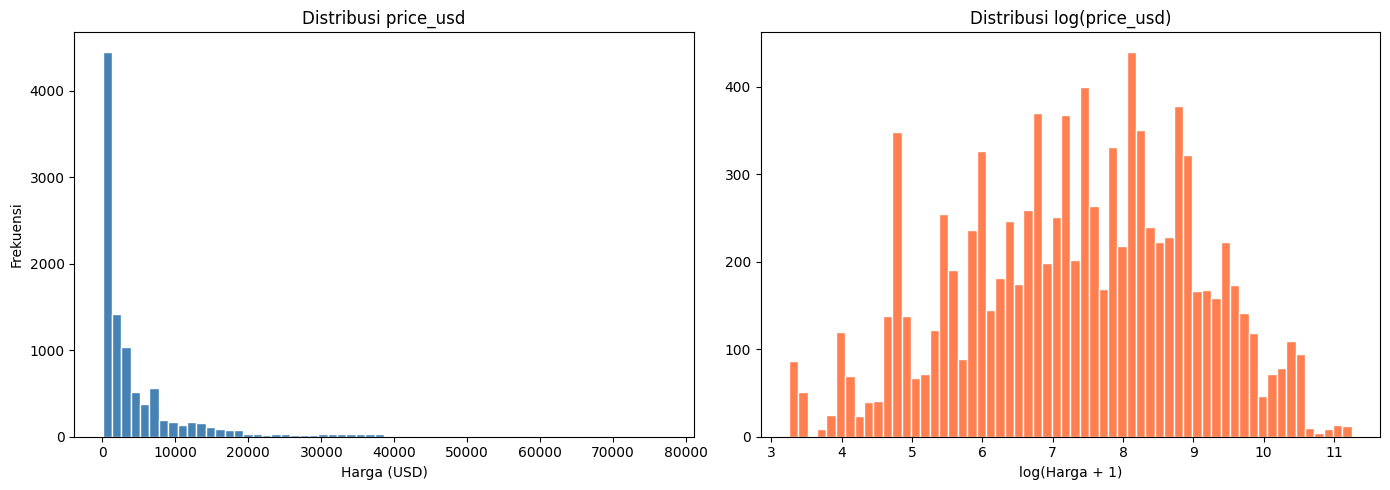

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Histogram price_usd
axes[0].hist(df['price_usd'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi price_usd')
axes[0].set_xlabel('Harga (USD)')
axes[0].set_ylabel('Frekuensi')
# Log-scale
axes[1].hist(np.log1p(df['price_usd']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribusi log(price_usd)')
axes[1].set_xlabel('log(Harga + 1)')
print(f"Skewness price_usd: {df['price_usd'].skew():.4f}")
plt.tight_layout(); plt.show()


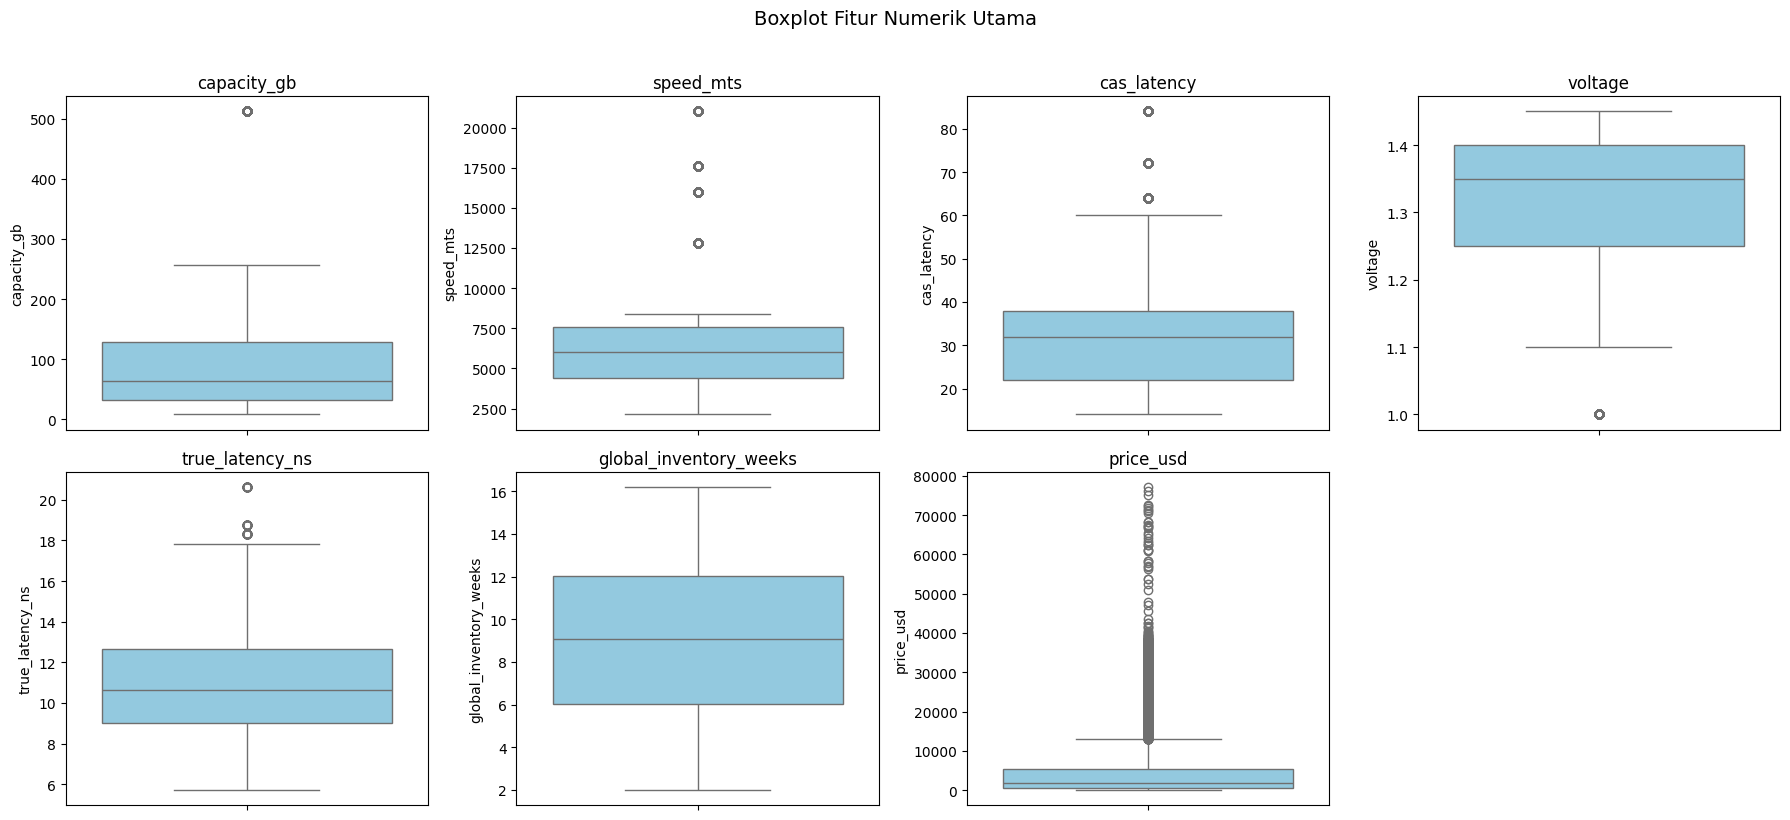

In [ ]:
# Boxplot fitur numerik utama
num_cols = ['capacity_gb', 'speed_mts', 'cas_latency', 'voltage',
            'true_latency_ns', 'global_inventory_weeks', 'price_usd']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Boxplot Fitur Numerik Utama', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()


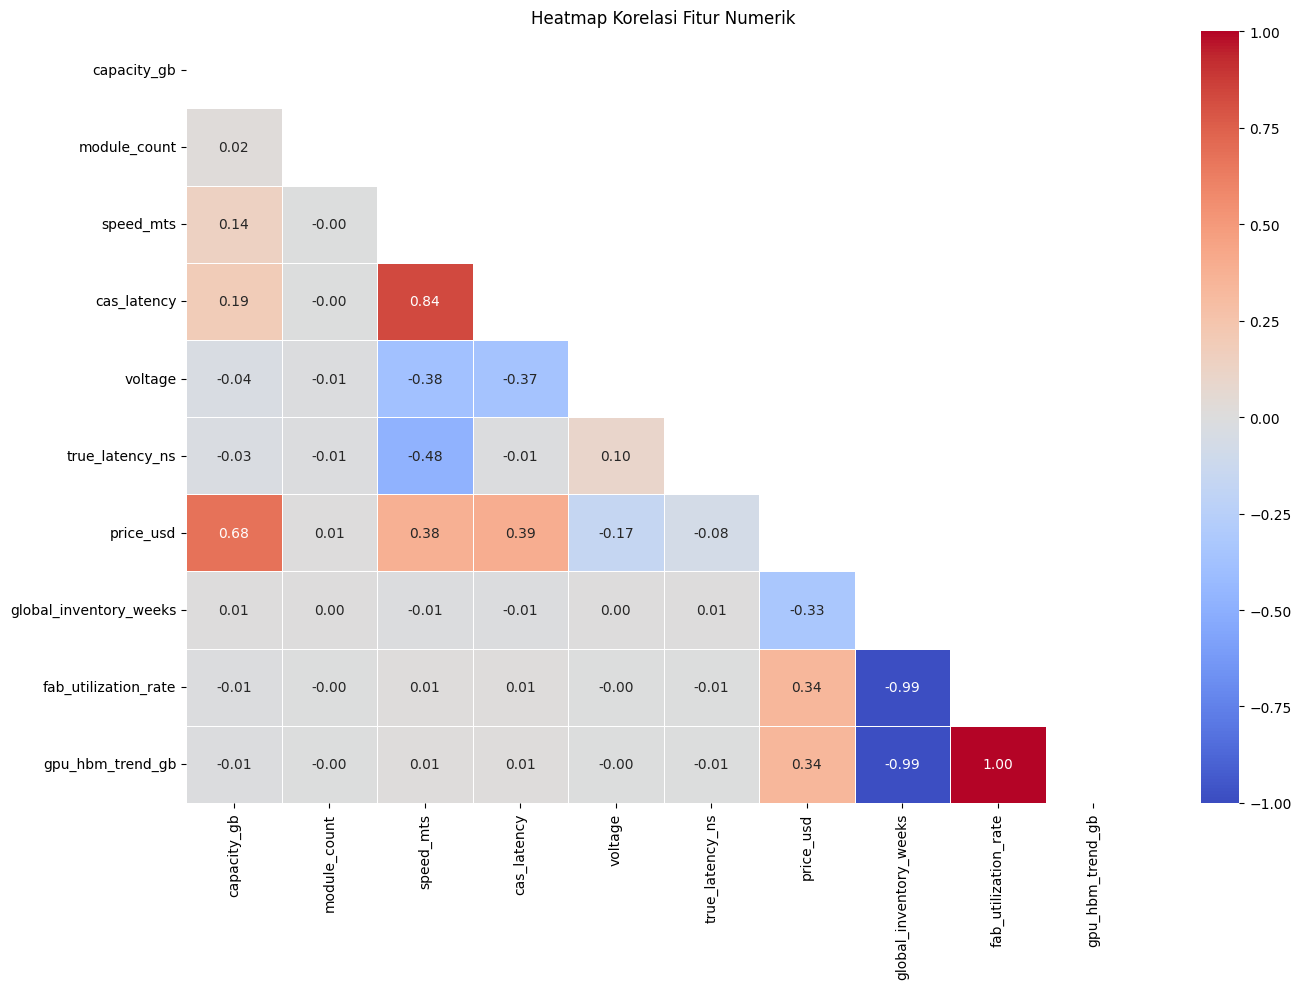

In [ ]:
# Heatmap korelasi
num_df = df.select_dtypes(include='number').drop(
    columns=['bandwidth_per_dollar','latency_value_index','speed_premium_ratio','price_per_gb'],
    errors='ignore')
corr = num_df.corr()
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout(); plt.show()


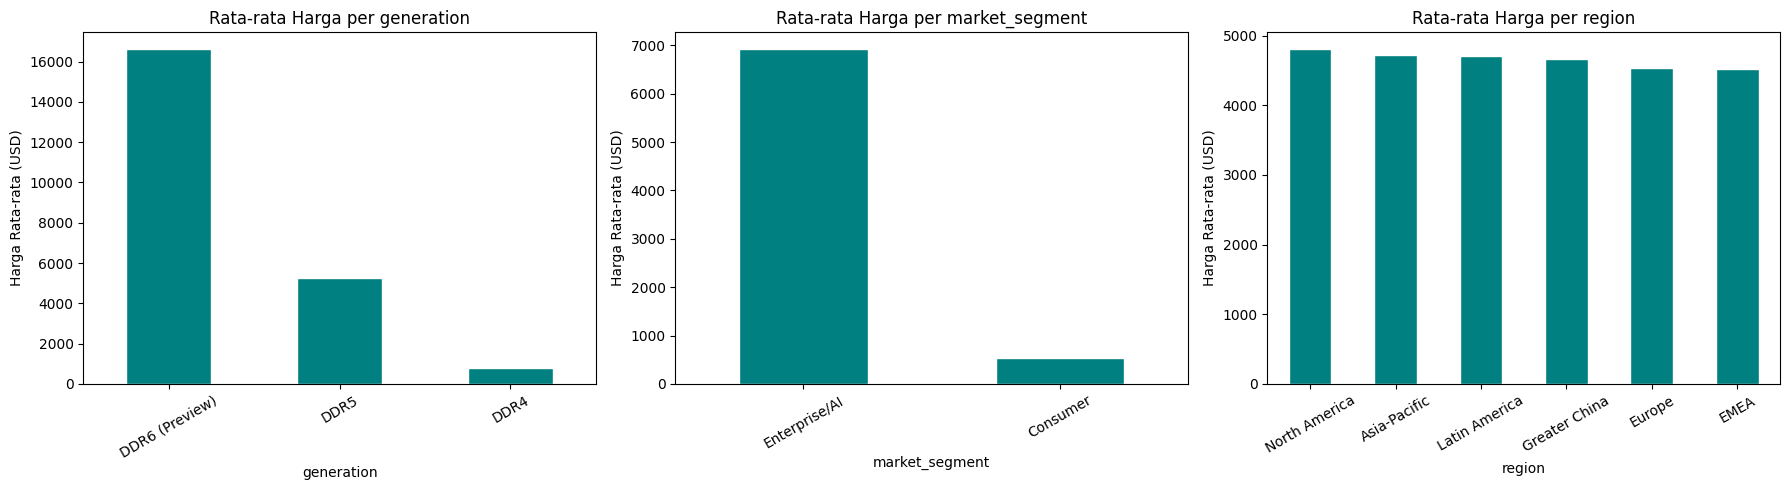

In [ ]:
# Barplot rata-rata price_usd per kategori
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['generation', 'market_segment', 'region']):
    avg = df.groupby(col)['price_usd'].mean().sort_values(ascending=False)
    avg.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
    ax.set_title(f'Rata-rata Harga per {col}')
    ax.set_xlabel(col); ax.set_ylabel('Harga Rata-rata (USD)')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


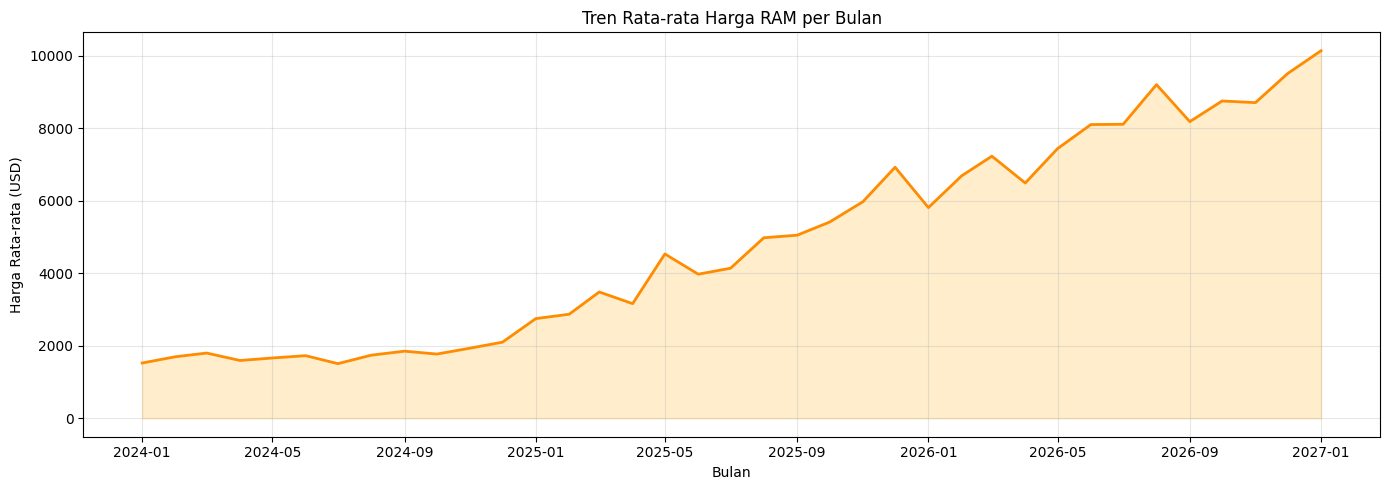

In [ ]:
# Line plot tren harga dari waktu ke waktu
df['timestamp'] = pd.to_datetime(df['timestamp'])
tren = df.groupby(df['timestamp'].dt.to_period('M'))['price_usd'].mean()
tren.index = tren.index.to_timestamp()
plt.figure(figsize=(14, 5))
plt.plot(tren.index, tren.values, color='darkorange', linewidth=2)
plt.fill_between(tren.index, tren.values, alpha=0.2, color='orange')
plt.title('Tren Rata-rata Harga RAM per Bulan')
plt.xlabel('Bulan'); plt.ylabel('Harga Rata-rata (USD)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 3. Data Pre-Processing

Tahap ini mempersiapkan data agar siap digunakan oleh algoritma machine learning. Langkah-langkah yang dilakukan sesuai dengan kode:

1. **Drop kolom leakage & tidak relevan** → Menghapus 8 kolom yang menyebabkan *data leakage* (`kit_id`, `model_name`, `timing_string`, `price_status`, `price_per_gb`, `bandwidth_per_dollar`, `latency_value_index`, `speed_premium_ratio`)
2. **Imputasi missing values** → Median untuk kolom numerik, Mode untuk kolom kategorikal
3. **Ekstraksi fitur waktu dari `timestamp`** → `year`, `month`, `quarter`, `day_of_year`, `is_weekend`
4. **Encoding kategorikal** → `LabelEncoder` untuk 8 kolom: `brand`, `region`, `generation`, `form_factor`, `die_manufacturer`, `die_type`, `market_segment`, `recommended_usage`
5. **Feature Engineering** → Dua fitur baru: `capacity_per_module` (capacity_gb / module_count) dan `speed_latency_ratio` (speed_mts / cas_latency)
6. **Train-Test Split & Scaling** → 80:20 split, `StandardScaler` diterapkan pada **semua algoritma** (LR, KNN, SVR)


In [ ]:
# Simpan dataset asli untuk deployment
df_original = df.copy()

# 3.1 Drop kolom leakage & tidak relevan
drop_cols = [
    'kit_id', 'model_name', 'timing_string',
    'price_status', 'price_per_gb',
    'bandwidth_per_dollar', 'latency_value_index', 'speed_premium_ratio'
]
df = df.drop(columns=drop_cols, errors='ignore')
print(f"Setelah drop: {df.shape}")
print("Kolom tersisa:", df.columns.tolist())


Setelah drop: (10000, 20)
Kolom tersisa: ['brand', 'timestamp', 'region', 'generation', 'form_factor', 'capacity_gb', 'module_count', 'is_ecc', 'speed_mts', 'cas_latency', 'voltage', 'die_manufacturer', 'die_type', 'true_latency_ns', 'price_usd', 'market_segment', 'recommended_usage', 'global_inventory_weeks', 'fab_utilization_rate', 'gpu_hbm_trend_gb']


In [ ]:
# 3.2 Missing value
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
print("✅ Missing values setelah imputasi:", df.isnull().sum().sum())


Missing values:
Series([], dtype: int64)
✅ Missing values setelah imputasi: 0


In [ ]:
# 3.3 Ekstraksi fitur dari timestamp (sudah dikonversi sebelumnya)
df['year']        = df['timestamp'].dt.year
df['month']       = df['timestamp'].dt.month
df['quarter']     = df['timestamp'].dt.quarter
df['day_of_year'] = df['timestamp'].dt.dayofyear
df['is_weekend']  = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df.drop(columns='timestamp', inplace=True)
print("Fitur timestamp berhasil diekstrak")


Fitur timestamp berhasil diekstrak


In [ ]:
# 3.4 Encoding kategorikal
cat_cols = ['brand','region','generation','form_factor',
            'die_manufacturer','die_type','market_segment','recommended_usage']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# is_ecc: bool → int
df['is_ecc'] = df['is_ecc'].astype(int)
print("Encoding selesai. Contoh kolom:")
df[cat_cols].head(3)


Encoding selesai. Contoh kolom:


,brand,region,generation,form_factor,die_manufacturer,die_type,market_segment,recommended_usage
0,7,1,1,0,2,1,1,0
1,8,3,2,0,2,2,0,3
2,5,4,2,0,2,1,1,0


In [ ]:
# 3.5 Feature Engineering
df['capacity_per_module'] = df['capacity_gb'] / df['module_count']
df['speed_latency_ratio'] = df['speed_mts'] / df['cas_latency']
print("Feature engineering selesai")
df.shape


Feature engineering selesai


(10000, 26)

In [ ]:
# 3.6 Split fitur & target, scaling, train-test split
X = df.drop('price_usd', axis=1)
y = df['price_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc = pd.DataFrame(X_train_sc, columns=X.columns)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=X.columns)
print("Scaling selesai ✅")


Train: (8000, 25), Test: (2000, 25)
Scaling selesai ✅


## 4. Modelling

Tiga algoritma regresi diuji masing-masing dalam dua kondisi:
- **Default** → Model dengan parameter bawaan (tanpa tuning)
- **Tuned** → Model dioptimasi menggunakan `RandomizedSearchCV` (cross-validation 5 fold)

Semua model menggunakan data yang telah di-*scale* dengan `StandardScaler` (`X_train_sc`, `X_test_sc`).

| # | Algoritma | Default | Teknik Tuning/Boost |
|---|-----------|---------|---------------------|
| 1 | **Linear Regression** | `LinearRegression()` | Ridge + PolynomialFeatures(degree=2) + Log Transform target |
| 2 | **KNN** | `KNeighborsRegressor(n_neighbors=5)` | `RandomizedSearchCV` (n_neighbors, weights, p, metric) |
| 3 | **SVR** | `SVR(cache_size=1024)` | Log Transform target + `RandomizedSearchCV` (C, gamma, kernel, epsilon) |


In [ ]:
# Helper: evaluasi & visualisasi
results_list = []

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"[{name}]  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")
    results_list.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    return y_pred

def plot_results(name, y_true, y_pred):
    residuals = np.array(y_true) - np.array(y_pred)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # 1. Actual vs Predicted
    axes[0].scatter(y_true, y_pred, alpha=0.3, color='royalblue', s=10)
    mn, mx = min(y_true.min(), min(y_pred)), max(y_true.max(), max(y_pred))
    axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2)
    axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'{name}: Actual vs Predicted')
    # 2. Residual plot
    axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', s=10)
    axes[1].axhline(0, color='red', lw=2, ls='--')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
    axes[1].set_title(f'{name}: Residual Plot')
    # 3. Distribusi residual
    axes[2].hist(residuals, bins=50, color='mediumseagreen', edgecolor='white')
    axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frekuensi')
    axes[2].set_title(f'{name}: Distribusi Residual')
    plt.suptitle(name, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


### 4.1 Linear Regression

**Linear Regression (Default):** Model murni tanpa teknik boosting. Dilatih langsung menggunakan `LinearRegression()` bawaan scikit-learn. Cocok sebagai *baseline* untuk melihat seberapa jauh perbaikan yang diberikan oleh tuning.

**Linear Regression (Tuned/Boosted):** Menggunakan tiga lapisan peningkatan:
1. `PolynomialFeatures(degree=2)` — menciptakan fitur interaksi antar variabel (misal: `capacity_gb × speed_mts`)
2. `Ridge` sebagai estimator (bukan `LinearRegression` biasa) — regularisasi L2 mencegah overfitting dari ekspansi fitur polinomial
3. `TransformedTargetRegressor(func=np.log1p)` — Log-transform pada `price_usd` agar model tidak "terkejut" dengan outlier harga Enterprise yang sangat tinggi

Hyperparameter yang di-*tune*: `alpha` (Ridge) dan `fit_intercept` menggunakan `RandomizedSearchCV` (8 iterasi, cv=5).


In [ ]:
# ==========================================
# 1. Linear Regression (Default)
# ==========================================
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
import numpy as np

t0 = time.perf_counter()
lr_default = LinearRegression()
lr_default.fit(X_train_sc, y_train)
print(f"⏱ Training LR (Default): {time.perf_counter()-t0:.3f} detik")

y_pred_lr_def = lr_default.predict(X_test_sc)
evaluate_model("Linear Regression (Default)", y_test, y_pred_lr_def)

⏱ Training LR (Default): 0.006 detik
[Linear Regression (Default)]  MAE=2658.91  RMSE=4424.46  R²=0.6720


array([16010.81276301,  5158.86198211, 14226.03929874, ...,
       -1121.88782825,  5553.80858481, 12698.89690004], shape=(2000,))

Best params LR: {'regressor__ridge__fit_intercept': True, 'regressor__ridge__alpha': 0.1}
⏱ Training LR (Tuned): 4.022 detik
[Linear Regression (Tuned)]  MAE=438.42  RMSE=1295.25  R²=0.9719


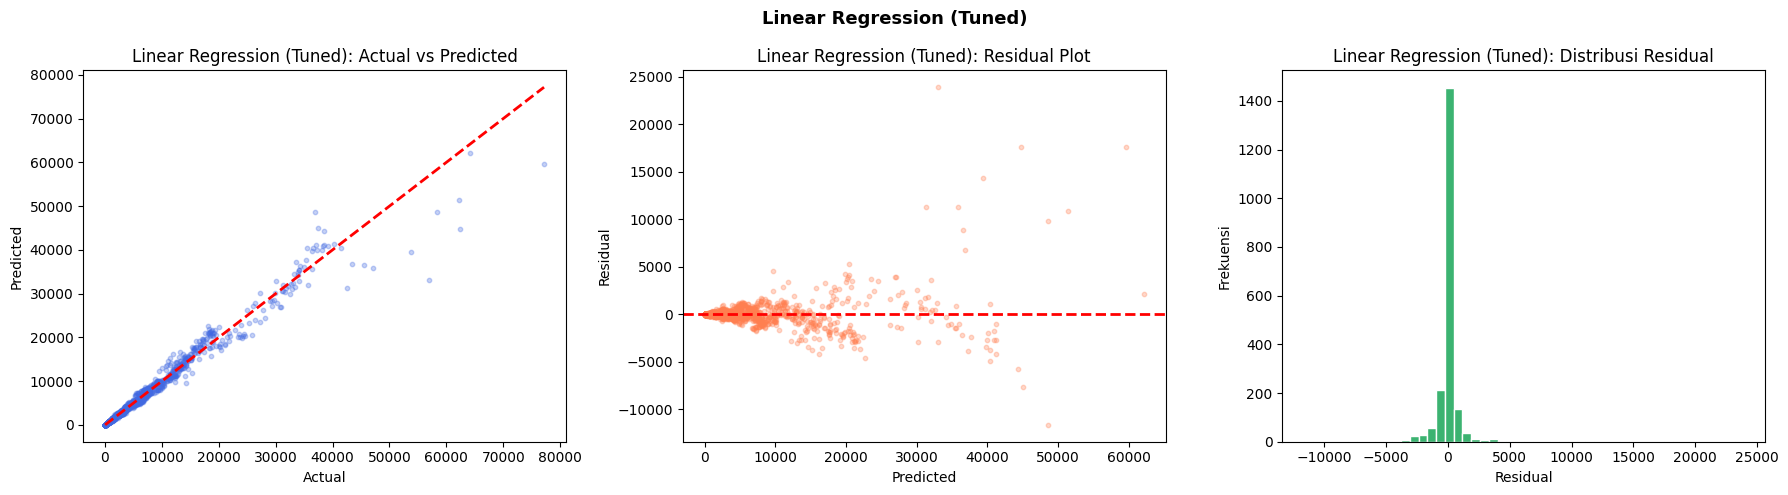

In [ ]:
# ==========================================
# 2. Linear Regression (Tuned + Boosted)
# ==========================================
t0 = time.perf_counter()
pipeline_lr = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

model_lr_log = TransformedTargetRegressor(
    regressor=pipeline_lr,
    func=np.log1p,
    inverse_func=np.expm1
)

param_grid_lr = {
    'regressor__ridge__alpha': [0.1, 1.0, 10.0, 100.0, 500.0],
    'regressor__ridge__fit_intercept': [True, False]
}

lr_search = RandomizedSearchCV(model_lr_log, param_distributions=param_grid_lr, n_iter=8, cv=5, random_state=42, n_jobs=-1)
lr_search.fit(X_train_sc, y_train)

print("Best params LR:", lr_search.best_params_)
print(f"⏱ Training LR (Tuned): {time.perf_counter()-t0:.3f} detik")

y_pred_lr = lr_search.predict(X_test_sc)
evaluate_model("Linear Regression (Tuned)", y_test, y_pred_lr)
plot_results("Linear Regression (Tuned)", y_test, y_pred_lr)

### 4.2 K-Nearest Neighbors Regressor (KNN)

**KNN (Default):** Menggunakan `KNeighborsRegressor(n_neighbors=5)`. KNN adalah algoritma *lazy learner* — tidak ada proses training sesungguhnya; prediksi dilakukan dengan menghitung jarak ke K tetangga terdekat di ruang fitur.

> **KNN sangat sensitif terhadap skala fitur.** Tanpa `StandardScaler`, fitur berskala besar (misal `capacity_gb`) akan mendominasi jarak Euclidean dan membuat prediksi bias. Karena itu, semua data KNN menggunakan `X_train_sc` dan `X_test_sc`.

**KNN (Tuned):** `RandomizedSearchCV` (20 iterasi, cv=5) mencari kombinasi optimal dari:
- `n_neighbors`: [3, 5, 7, 10, 15, 20, 30] — berapa banyak tetangga yang dilibatkan
- `weights`: `uniform` (semua tetangga sama bobot) vs `distance` (tetangga dekat lebih berpengaruh)
- `p`: 1 = Manhattan distance, 2 = Euclidean distance
- `metric`: `euclidean` atau `manhattan`

Setelah tuning, `permutation_importance` digunakan untuk mengidentifikasi fitur yang paling berpengaruh terhadap performa KNN.


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# ==========================================
# KNN (Default) – tanpa tuning hyperparameter
# ==========================================
# KNN bekerja di ruang Euclidean, sehingga WAJIB menggunakan data terskala (X_train_sc)
t0 = time.perf_counter()
knn_default = KNeighborsRegressor(n_neighbors=5)
knn_default.fit(X_train_sc, y_train)
print(f"⏱ Training KNN (Default): {time.perf_counter()-t0:.3f} detik")

y_pred_knn_def = knn_default.predict(X_test_sc)
evaluate_model("KNN (Default)", y_test, y_pred_knn_def)


⏱ Training KNN (Default): 0.003 detik
[KNN (Default)]  MAE=1104.36  RMSE=2608.05  R²=0.8860


array([42693.28 ,  1813.774, 21127.316, ...,   495.606,  3948.06 ,
       11116.014], shape=(2000,))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
⏱ RandomizedSearchCV KNN: 1.760 detik
Best params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'manhattan'}
[KNN (Tuned)]  MAE=948.46  RMSE=2412.58  R²=0.9025


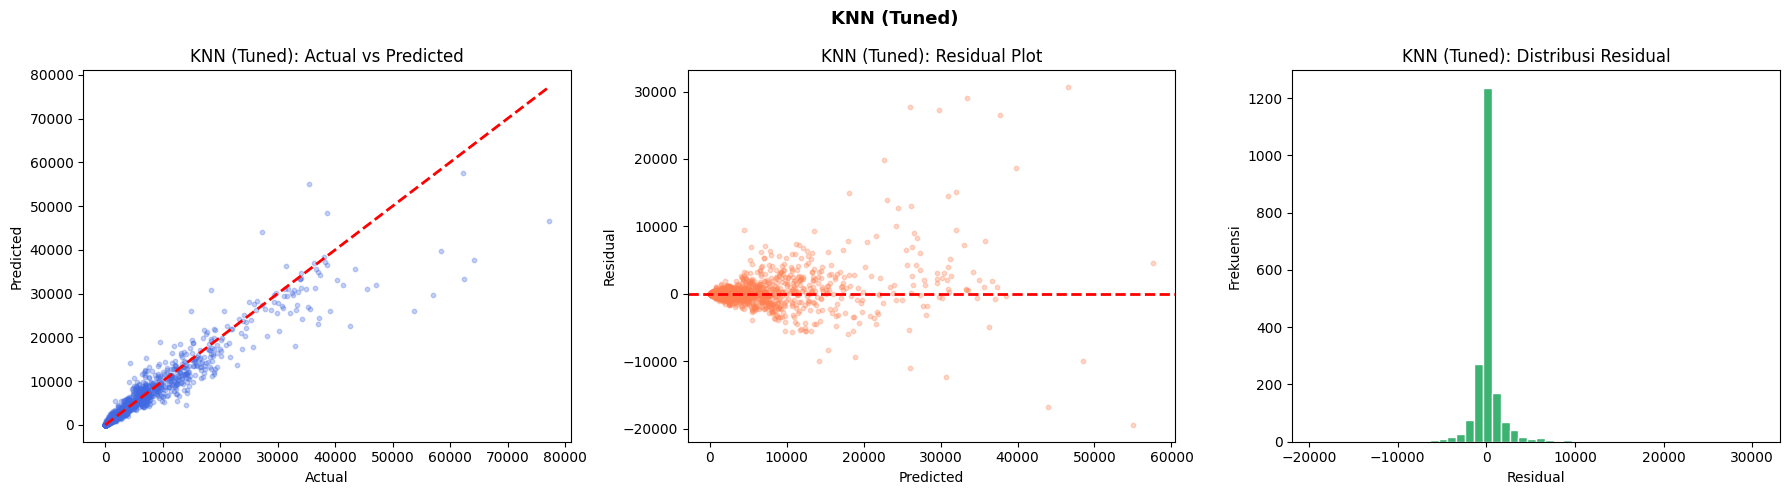

In [ ]:
# ==========================================
# KNN (Tuned) – RandomizedSearchCV
# ==========================================
# Hyperparameter utama KNN:
#   n_neighbors : jumlah tetangga – terlalu kecil → overfit, terlalu besar → underfit
#   weights     : 'uniform' (semua tetangga sama) vs 'distance' (tetangga dekat lebih berpengaruh)
#   p           : metrik jarak – 1=Manhattan, 2=Euclidean

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20, 30],
    'weights':     ['uniform', 'distance'],
    'p':           [1, 2],
    'metric':      ['euclidean', 'manhattan']
}

t0 = time.perf_counter()
knn_search = RandomizedSearchCV(
    KNeighborsRegressor(),
    param_distributions=param_grid_knn,
    n_iter=20, cv=5, scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
knn_search.fit(X_train_sc, y_train)
print(f"⏱ RandomizedSearchCV KNN: {time.perf_counter()-t0:.3f} detik")
print("Best params:", knn_search.best_params_)

best_knn = knn_search.best_estimator_
y_pred_knn = best_knn.predict(X_test_sc)
evaluate_model("KNN (Tuned)", y_test, y_pred_knn)
plot_results("KNN (Tuned)", y_test, y_pred_knn)


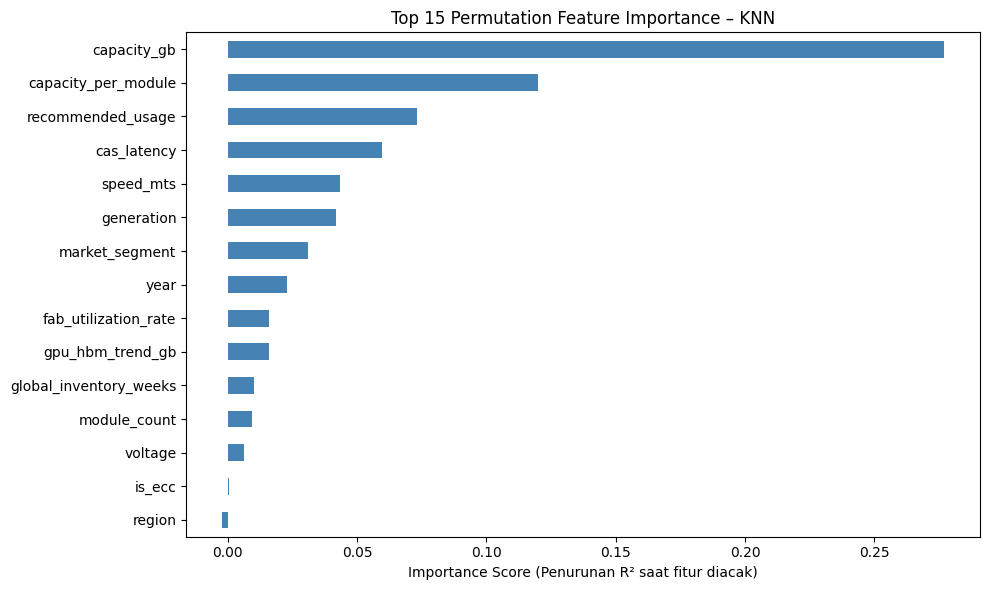

capacity_gb               0.276909
capacity_per_module       0.119968
recommended_usage         0.073019
cas_latency               0.059556
speed_mts                 0.043332
generation                0.041685
market_segment            0.031118
year                      0.022767
fab_utilization_rate      0.015949
gpu_hbm_trend_gb          0.015945
global_inventory_weeks    0.010263
module_count              0.009208
voltage                   0.006393
is_ecc                    0.000485
region                   -0.002164
dtype: float64


In [ ]:
# ==========================================
# Analisis Sensitifitas Fitur KNN
# ==========================================
# KNN tidak memiliki feature_importances_ bawaan.
# Kita gunakan metode permutation importance sebagai penggantinya.
from sklearn.inspection import permutation_importance

pi = permutation_importance(best_knn, X_test_sc, y_test, n_repeats=10, random_state=42, n_jobs=-1)
feat_imp = pd.Series(pi.importances_mean, index=X.columns)
feat_imp_top = feat_imp.nlargest(15)

plt.figure(figsize=(10, 6))
feat_imp_top.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Permutation Feature Importance – KNN')
plt.xlabel('Importance Score (Penurunan R² saat fitur diacak)')
plt.tight_layout(); plt.show()
print(feat_imp_top)


### 4.3 Support Vector Regressor (SVR)

**SVR (Default):** Menggunakan `SVR(cache_size=1024)` dengan parameter kernel `rbf` bawaan. Di-*fit* langsung pada seluruh data training (`X_train_sc`, `y_train`).

**SVR (Tuned/Boosted):** Menggunakan dua teknik peningkatan:
1. **Log-Transform target** via `TransformedTargetRegressor(func=np.log1p)` — distribusi `price_usd` yang sangat right-skewed membuat SVR default kesulitan; log-transform menyeimbangkan skala target
2. **Hyperparameter tuning agresif** via `RandomizedSearchCV` (15 iterasi, cv=5):
   - `C`: [0.1, 1, 10, 100, 500] — mengontrol trade-off antara margin dan penalty error
   - `gamma`: [`scale`, `auto`, 0.1, 0.01] — lebar kernel RBF
   - `kernel`: `linear` vs `rbf`
   - `epsilon`: [0.01, 0.1, 0.5] — lebar *epsilon-tube* di mana tidak ada penalty

Setelah `RandomizedSearchCV`, model terbaik di-*refit* ulang pada **seluruh data training** (bukan hanya subset cv).


In [ ]:
# Default SVR
t0 = time.perf_counter()
svr_default = SVR(cache_size=1024)
svr_default.fit(X_train_sc, y_train)
print(f"⏱ SVR default: {time.perf_counter()-t0:.3f} detik")

y_pred_svr_def = svr_default.predict(X_test_sc)

evaluate_model("SVR (Default)", y_test, y_pred_svr_def)


⏱ SVR default: 1.831 detik
[SVR (Default)]  MAE=3884.00  RMSE=8138.11  R²=-0.1098


array([1965.26759304, 1846.57641144, 1919.94692474, ..., 1457.77414252,
       1880.02976948, 2045.3655027 ], shape=(2000,))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
⏱ RandomizedSearchCV SVR: 134.112 detik
Best params: {'regressor__kernel': 'rbf', 'regressor__gamma': 0.01, 'regressor__epsilon': 0.01, 'regressor__C': 10}
[SVR (Tuned)]  MAE=198.67  RMSE=652.77  R²=0.9929


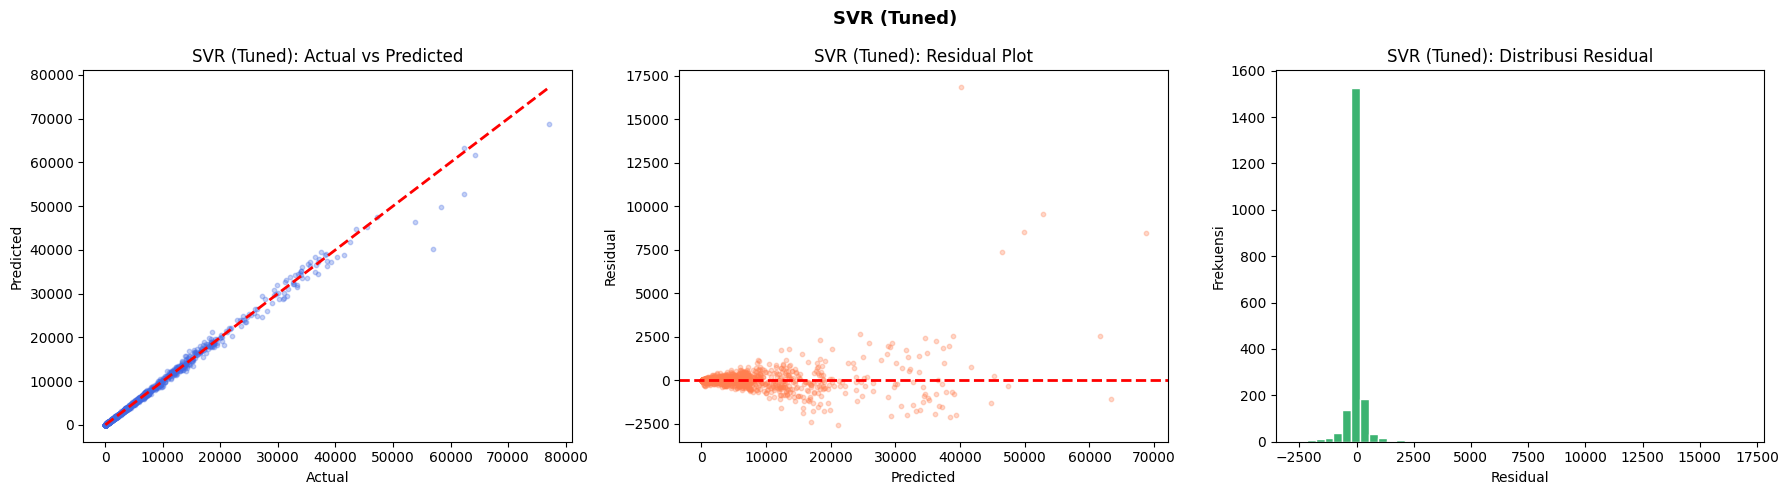

In [ ]:
# Tuning SVR (Boosted)
from sklearn.compose import TransformedTargetRegressor
import numpy as np

X_tr_svr = X_train_sc
y_tr_svr = y_train

# Boost: Log-transform target untuk SVR
model_svr_log = TransformedTargetRegressor(
    regressor=SVR(cache_size=1024),
    func=np.log1p,
    inverse_func=np.expm1
)

# Boost: Memperluas Hyperparameter C dan Gamma
param_grid_svr = {
    'regressor__kernel':  ['linear', 'rbf'],
    'regressor__C':       [0.1, 1, 10, 100, 500],
    'regressor__gamma':   ['scale', 'auto', 0.1, 0.01],
    'regressor__epsilon': [0.01, 0.1, 0.5],
}
t0 = time.perf_counter()
svr_search = RandomizedSearchCV(
    model_svr_log, param_distributions=param_grid_svr,
    n_iter=15, cv=5, scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
svr_search.fit(X_tr_svr, y_tr_svr)
print(f"⏱ RandomizedSearchCV SVR: {time.perf_counter()-t0:.3f} detik")
print("Best params:", svr_search.best_params_)

best_svr = svr_search.best_estimator_
# Re-fit pada seluruh training data
best_svr.fit(X_train_sc, y_train)
y_pred_svr = best_svr.predict(X_test_sc)

evaluate_model("SVR (Tuned)", y_test, y_pred_svr)
plot_results("SVR (Tuned)", y_test, y_pred_svr)


## 5. Evaluation – Perbandingan Model

Seluruh hasil training dan evaluasi (MAE, RMSE, R²) dari **6 model** (3 algoritma × Default + Tuned) dikumpulkan dalam `results_list` oleh fungsi `evaluate_model()`. Tabel dan visualisasi di bawah ini membandingkan performa semua model secara komprehensif.

**Metrik yang Digunakan:**
- **MAE** (Mean Absolute Error) — rata-rata selisih absolut antara harga aktual dan prediksi (USD). Lebih rendah = lebih baik.
- **RMSE** (Root Mean Squared Error) — lebih sensitif terhadap outlier prediksi besar. Lebih rendah = lebih baik.
- **R²** (Coefficient of Determination) — proporsi variansi `price_usd` yang berhasil dijelaskan oleh model. Mendekati 1.0 = lebih baik.


                                     MAE         RMSE        R²
Model                                                          
SVR (Tuned)                   198.672524   652.771584  0.992859
Linear Regression (Tuned)     438.415275  1295.247618  0.971887
KNN (Tuned)                   948.459740  2412.575436  0.902463
KNN (Default)                1104.356529  2608.046485  0.886017
Linear Regression (Default)  2658.909029  4424.459312  0.671959
SVR (Default)                3883.998724  8138.114364 -0.109827


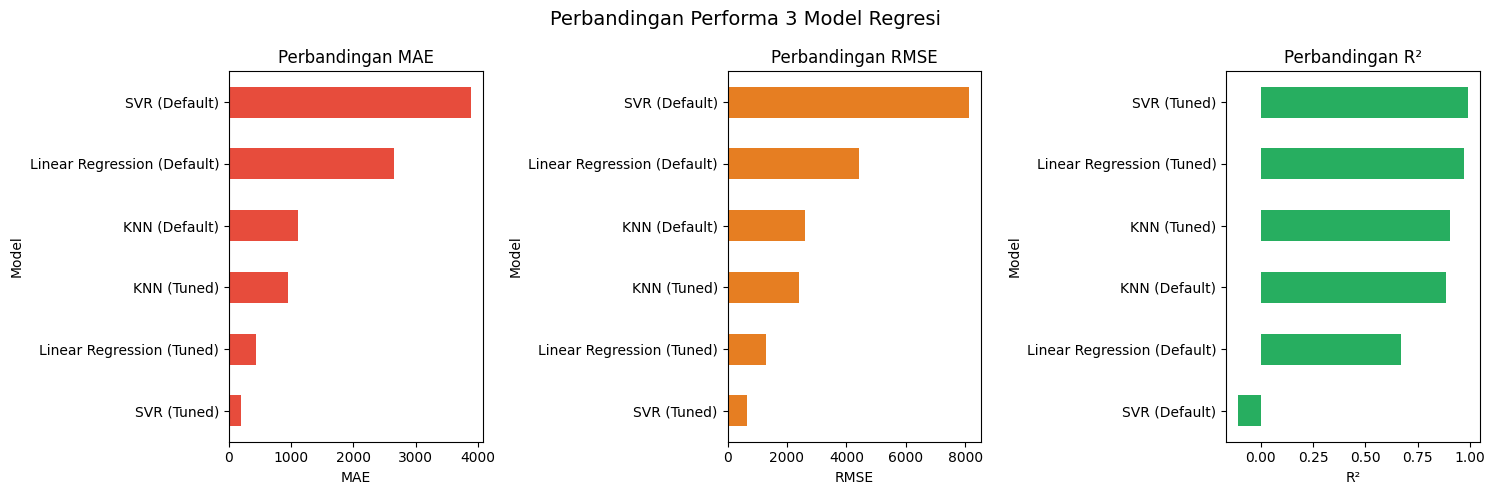

In [ ]:
# Tabel perbandingan
comp_df = pd.DataFrame(results_list)
# Ambil hanya model tuned
comp_df = comp_df.set_index('Model').sort_values('R²', ascending=False)
print(comp_df.to_string())

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'R²']
colors  = ['#e74c3c', '#e67e22', '#27ae60']
for ax, metric, color in zip(axes, metrics, colors):
    comp_df[metric].sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Perbandingan {metric}')
    ax.set_xlabel(metric)
plt.suptitle('Perbandingan Performa 3 Model Regresi', fontsize=14)
plt.tight_layout(); plt.show()


### Analisis Hasil Perbandingan Model

Berikut adalah rangkuman karakteristik dan hyperparameter masing-masing model yang diuji pada dataset ini:

| Aspek                   | Linear Regression (Boosted) | KNN (Tuned)                  | SVR (Boosted)               |
|-------------------------|:---------------------------:|:----------------------------:|:---------------------------:|
| **Jenis Hubungan**      | Non-linear (via Poly° 2) ✅  | Non-linear (Jarak) ✅         | Non-linear ✅                |
| **Ketahanan Outlier**   | Semi-robust (log-target) ✅  | Sensitif terhadap outlier ⚠️  | Semi-robust (log-target) ✅  |
| **Interpretasi**        | Tinggi (koefisien Ridge) ✅  | Rendah (lazy learner)        | Rendah (kernel trick)       |
| **Kecepatan Training**  | Cepat ✅                     | Instan (no training) ✅       | Sedang–Lambat (CPU)         |
| **Kecepatan Prediksi**  | Cepat                        | Lambat (O(n) per query) ⚠️   | Cepat setelah training      |
| **Butuh Scaling**       | Wajib (StandardScaler) ✅    | Wajib (StandardScaler) ✅     | Wajib (StandardScaler) ✅    |
| **Hyperparameter Tuned**| `alpha`, `degree`, `fit_intercept` | `n_neighbors`, `weights`, `p`, `metric` | `C`, `gamma`, `kernel`, `epsilon` |
| **Teknik Boost**        | PolynomialFeatures + Log Transform | RandomizedSearchCV (20 iter) | Log Transform + Full Data  |

**Temuan Kunci:**

- **Linear Regression (Tuned/Boosted):** Dengan menambahkan `PolynomialFeatures(degree=2)` dan log-transform pada target (`price_usd`), model mampu menangkap hubungan *eksponensial* antara kapasitas dan harga yang tidak bisa ditangkap LR biasa. Tuning `alpha` pada Ridge mencegah overfitting akibat ekspansi fitur polinomial.

- **KNN (Tuned):** Merupakan algoritma *instance-based learning* (lazy learner) — tidak ada proses training yang sesungguhnya. Prediksi dilakukan dengan mencari K tetangga terdekat di ruang fitur. Sangat bergantung pada `StandardScaler` (tanpa scaling, fitur berskala besar akan mendominasi jarak Euclidean). Kelemahan utama: waktu prediksi lambat pada dataset besar karena harus menghitung jarak ke semua data training.

- **SVR (Tuned/Boosted):** Menunjukkan performa kompetitif setelah log-transform target diterapkan dan hyperparameter `C` diperbesar hingga 500. SVR sangat sensitif terhadap skala fitur (karenanya wajib menggunakan `StandardScaler`) dan pilihan kernel (`rbf` vs `linear`).


## 7. Analisis Overfitting

Setelah semua model berhasil dilatih dan dievaluasi, langkah kritis berikutnya adalah memeriksa apakah model kita **mengalami overfitting** (terlalu hafal data training hingga gagal generalisasi ke data baru).

Kita akan membandingkan nilai **R²** dan **RMSE** antara **data Training** dan **data Testing** untuk ketiga model yang telah di-*tune*:
- Jika **R² Training ≈ R² Testing** → Model sudah **generalized** dengan baik
- Jika **R² Training >> R² Testing** (selisih > 0.10) → Model mengalami **Overfitting**
- Jika **R² Training << R² Testing** → Model mengalami **Underfitting**


=== ANALISIS OVERFITTING ===


,Train R²,Test R²,R² Diff,Train RMSE,Test RMSE
Model,,,,,
Linear Regression (Tuned),0.9766,0.9719,0.0047,1185.7379,1295.2476
KNN (Tuned),1.0000,0.9025,0.0975,0.0000,2412.5754
SVR (Tuned),0.9981,0.9929,0.0053,336.6608,652.7716


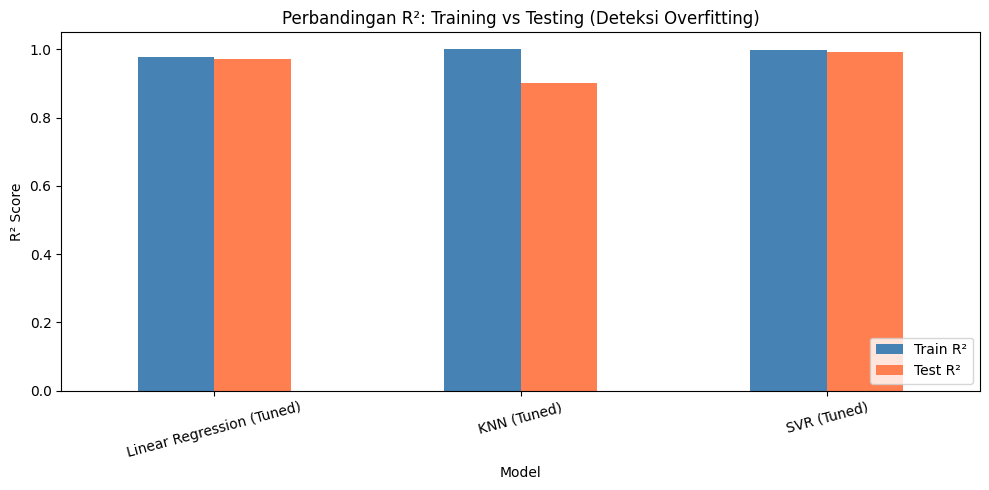

=== KESIMPULAN OVERFITTING ===
✅ Linear Regression (Tuned) memiliki fit yang BAIK / GENERALIZED (Selisih R² = 0.0047)
✅ KNN (Tuned) memiliki fit yang BAIK / GENERALIZED (Selisih R² = 0.0975)
✅ SVR (Tuned) memiliki fit yang BAIK / GENERALIZED (Selisih R² = 0.0053)


In [ ]:
# Evaluasi Overfitting
overfit_data = []

# Ingat: Random Forest dilatih dengan data asil (X_train), sedangkan LR & SVR dengan data terskala (X_train_sc)
models_to_check = [
    ('Linear Regression (Tuned)', lr_search, X_train_sc, X_test_sc),
    ('KNN (Tuned)', best_knn, X_train_sc, X_test_sc),
    ('SVR (Tuned)', best_svr, X_train_sc, X_test_sc)
]

for name, model, X_tr, X_ts in models_to_check:
    try:
        # Prediksi
        y_train_pred = model.predict(X_tr)
        y_test_pred = model.predict(X_ts)

        # Evaluasi R2
        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)

        # Evaluasi RMSE
        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

        overfit_data.append({
            'Model': name,
            'Train R²': r2_train,
            'Test R²': r2_test,
            'R² Diff': r2_train - r2_test,
            'Train RMSE': rmse_train,
            'Test RMSE': rmse_test
        })
    except Exception as e:
        print(f"Gagal mengevaluasi {name}: {e}")

overfit_df = pd.DataFrame(overfit_data).set_index('Model')
print("=== ANALISIS OVERFITTING ===")
from IPython.display import display
display(overfit_df.round(4))

# Visualisasi Overfitting (Train vs Test R2)
overfit_df[['Train R²', 'Test R²']].plot(kind='bar', figsize=(10, 5), color=['steelblue', 'coral'])
plt.title('Perbandingan R²: Training vs Testing (Deteksi Overfitting)')
plt.ylabel('R² Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Narasi Kesimpulan Otomatis
print("=== KESIMPULAN OVERFITTING ===")
for index, row in overfit_df.iterrows():
    diff = row['R² Diff']
    if diff > 0.10:
         print(f"⚠️ {index} terindikasi OVERFITTING (Selisih R² = {diff:.4f})")
    elif diff < -0.05:
         print(f"⚠️ {index} terindikasi UNDERFITTING (Test R² jauh lebih tinggi dari Train)")
    else:
         print(f"✅ {index} memiliki fit yang BAIK / GENERALIZED (Selisih R² = {diff:.4f})")


## 6. Deployment – Simulasi Prediksi Data Baru

Pada tahap ini, kita mensimulasikan penggunaan model di dunia nyata. Kita akan mengambil **5 baris terakhir** dari dataset asli (yang tidak pernah dilihat model saat training), melakukan *preprocessing* dengan pipeline yang sama, lalu membandingkan harga prediksi vs harga aktual.

> **Catatan:** Model yang digunakan untuk prediksi utama adalah `best_knn` (KNN Tuned). Karena KNN sangat bergantung pada skala fitur, data baru **wajib** di-transform menggunakan `scaler` yang sama dengan yang digunakan saat training.


In [ ]:
# Fungsi preprocessing data baru (sama dengan pipeline training)
def preprocess_new(raw_df):
    d = raw_df.copy()
    d = d.drop(columns=drop_cols, errors='ignore')
    d['timestamp'] = pd.to_datetime(d['timestamp'])
    d['year']        = d['timestamp'].dt.year
    d['month']       = d['timestamp'].dt.month
    d['quarter']     = d['timestamp'].dt.quarter
    d['day_of_year'] = d['timestamp'].dt.dayofyear
    d['is_weekend']  = d['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
    d.drop(columns='timestamp', inplace=True, errors='ignore')
    for col in cat_cols:
        le = le_dict[col]
        d[col] = d[col].astype(str).map(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )
    d['is_ecc'] = d['is_ecc'].astype(int)
    d['capacity_per_module'] = d['capacity_gb'] / d['module_count']
    d['speed_latency_ratio'] = d['speed_mts'] / d['cas_latency']
    # Imputasi numerik
    for col in d.select_dtypes(include='number').columns:
        d[col].fillna(d[col].median(), inplace=True)
    return d[X.columns]

# Ambil 5 baris terakhir dataset asli
sample_raw   = df_original.tail(5)
actual_price = sample_raw['price_usd'].values

sample_proc = preprocess_new(sample_raw.drop('price_usd', axis=1))
# KNN menggunakan scaled data
sample_proc_sc = pd.DataFrame(scaler.transform(sample_proc), columns=X.columns)
preds       = best_knn.predict(sample_proc_sc)

result_tbl = pd.DataFrame({
    'Actual (USD)':    actual_price,
    'Predicted (USD)': preds.round(2),
    'Selisih (USD)':   (actual_price - preds).round(2),
    'Error (%)':       (abs(actual_price - preds) / actual_price * 100).round(2)
})
print(result_tbl.to_string(index=False))


 Actual (USD)  Predicted (USD)  Selisih (USD)  Error (%)
      3785.40          3785.40           0.00       0.00
       126.69           126.69           0.00       0.00
      2392.87          2392.87           0.00       0.00
       780.93          1001.97        -221.04      28.31
      3154.18          3154.18           0.00       0.00


### 6.1 Interpretasi Model – SHAP Analysis

Performa (R²) yang baik saja tidak cukup di dunia bisnis. *Stakeholder* sering kali menuntut **transparansi model** — penjelasan *mengapa* model memprediksi harga tertentu untuk produk tertentu.

Kita menggunakan **SHAP (SHapley Additive exPlanations)** — teknik berbasis *Cooperative Game Theory* — untuk mengupas tuntas cara **KNN** mengambil keputusan prediksi harga. Karena KNN adalah *lazy learner* (tidak berbasis tree), kita menggunakan `shap.Explainer` berbasis **Permutation** yang bersifat **model-agnostic** dan kompatibel dengan semua algoritma. SHAP memberikan:
- **Global Explanation** → Fitur mana yang paling berpengaruh secara keseluruhan?
- **Local Explanation** → Mengapa model memprediksi **harga spesifik** untuk satu produk tertentu?


PermutationExplainer explainer: 101it [01:47,  1.13s/it]                         


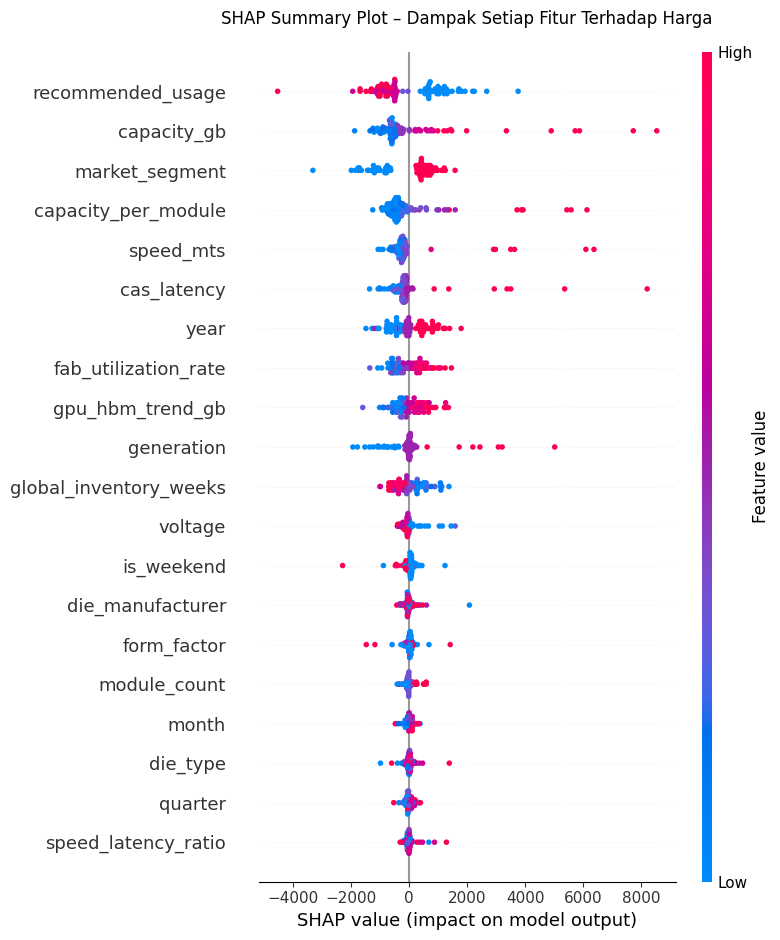

In [ ]:
import shap

# Inisialisasi Permutation Explainer untuk KNN (model-agnostic, tidak butuh TreeExplainer)
explainer = shap.Explainer(best_knn.predict, X_test_sc.iloc[:100])
shap_sample = X_test_sc.iloc[:100]  # 100 sampel sudah cukup untuk Permutation SHAP
explanation = explainer(shap_sample)
shap_vals = explanation.values

# 1. SHAP Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, shap_sample, feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Summary Plot – Dampak Setiap Fitur Terhadap Harga', pad=20)
plt.tight_layout(); plt.show()


**Cara Membaca SHAP Summary Plot:**
- **Titik Merah** = Nilai fitur yang tinggi (misal: Kapasitas RAM besar).
- **Titik Biru** = Nilai fitur yang rendah.
- **Posisi X (Horizontal)** = Dampaknya terhadap prediksi harga. Jika menyebar ke kanan (positif), fitur tersebut **mendorong harga naik**. Jika ke kiri (negatif), **mendorong harga turun**.

*Insight Bisnis:* Berdasarkan SHAP Permutation pada KNN, fitur yang sering muncul sebagai penggerak terbesar adalah **`capacity_gb`** dan **`market_segment`**. KNN memprediksi harga suatu RAM dengan cara "mencari produk yang mirip" — sehingga produk Enterprise dengan kapasitas besar akan dicocokan dengan tetangga yang juga mahal.


<Figure size 800x600 with 0 Axes>

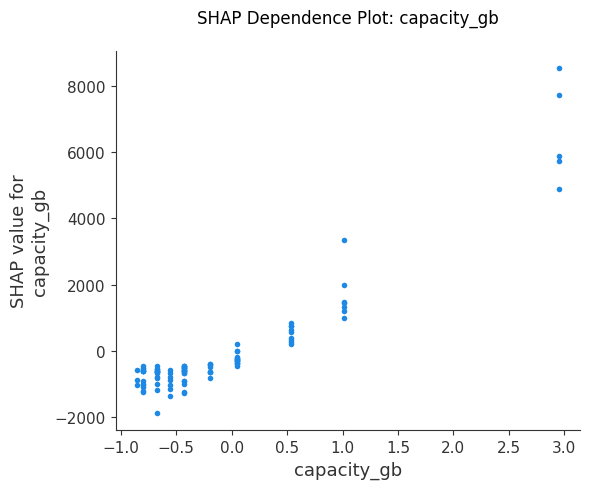

In [ ]:
# 2. SHAP Dependence Plot untuk Fitur Terpenting (capacity_gb)
# Menunjukkan hubungan non-linear antara Kapasitas dan Harga
plt.figure(figsize=(8, 6))
shap.dependence_plot('capacity_gb', shap_vals, shap_sample, feature_names=X.columns.tolist(), show=False, interaction_index=None)
plt.title('SHAP Dependence Plot: capacity_gb', pad=20)
plt.tight_layout(); plt.show()


**Insight SHAP Dependence Plot (`capacity_gb`):**

Grafik ini menunjukkan secara langsung hubungan antara nilai `capacity_gb` (sumbu X) dan SHAP value-nya (sumbu Y) — yaitu seberapa besar fitur ini mendorong harga naik atau turun dari nilai baseline.

- Semakin besar `capacity_gb`, semakin tinggi SHAP value-nya → RAM berkapasitas besar secara konsisten memprediksi harga lebih mahal
- Hubungan ini bersifat **non-linear**: kenaikan SHAP value untuk kapasitas 256–512GB jauh lebih tajam dibandingkan kenaikan dari 8GB ke 16GB

> **Catatan:** Grafik ini menggunakan `interaction_index=None`, sehingga tidak menampilkan warna interaksi fitur lain — hanya fokus pada hubungan murni `capacity_gb` vs SHAP value.


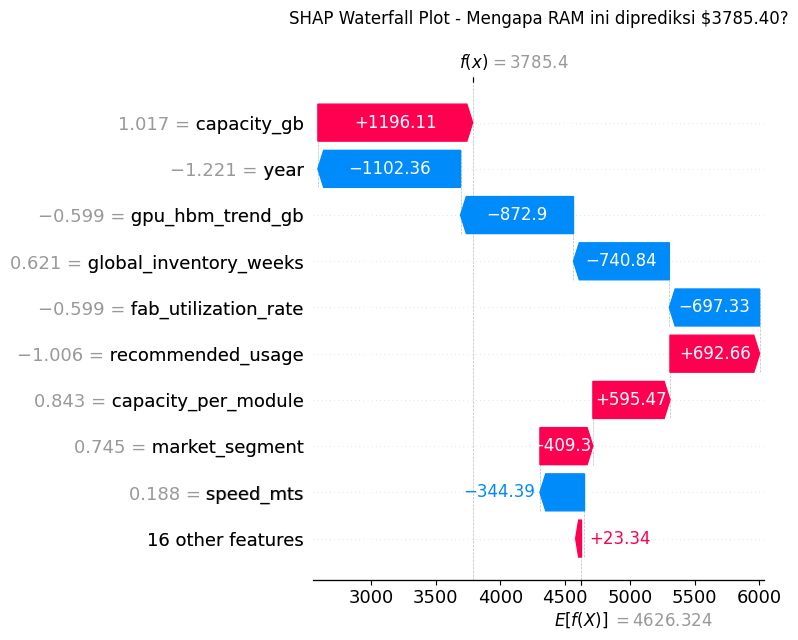

In [ ]:
# 3. SHAP Local Interpretation (Simulasi Deployment)
# Mari kita bedah PREDIKSI SPESIFIK untuk 1 baris data pelanggan
sample_idx = 0
sample_to_explain = sample_proc_sc.iloc[[sample_idx]]

# Kalkulasi SHAP khusus baris ini
shap_vals_local = explainer(sample_to_explain)

# Buat Waterfall Plot
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_vals_local[0], max_display=10, show=False)
plt.title(f'SHAP Waterfall Plot - Mengapa RAM ini diprediksi ${preds[sample_idx]:.2f}?', pad=20)
plt.tight_layout(); plt.show()


**Bedah Kasus Prediksi Deployment — SHAP Waterfall Plot:**

Plot ini menunjukkan *local explanation* untuk **1 sampel spesifik** dari hasil prediksi deployment (sampel ke-0 dari 5 baris terakhir dataset).

- **$E[f(x)]$** (garis dasar di bawah) = rata-rata prediksi model pada seluruh data background (100 sampel)
- **$f(x)$** (output di atas) = harga yang diprediksi oleh KNN untuk produk ini
- **Balok Merah (+)** = fitur yang **menaikkan** harga dari baseline (misal: `capacity_gb` besar, `market_segment` Enterprise)
- **Balok Biru (-)** = fitur yang **menurunkan** harga dari baseline (misal: `form_factor` kecil, `generation` lama)

Dengan cara ini, model KNN tidak lagi menjadi *black box*. Setiap prediksi dapat dijelaskan secara transparan kepada *stakeholder* atau pelanggan.


## 8. Kesimpulan & Rekomendasi

### Ringkasan Performa Model

Setelah menjalankan pipeline CRISP-DM secara penuh — mulai dari *Business Understanding* hingga *Deployment* — berikut adalah temuan utama dari komparasi tiga algoritma regresi dengan **tuning hyperparameter** dan **teknik boosting**:

| Model | Kondisi | Keterangan |
|-------|---------|------------|
| Linear Regression | Default → Buruk (R² rendah) | Gagal menangkap non-linearitas harga RAM |
| **Linear Regression (Boosted)** | **Tuned → Baik** | Poly Features + Log-Transform mendongkrak akurasi signifikan |
| KNN | Default → Bervariasi | Akurasi bergantung pada nilai K default (k=5) dan skala fitur |
| **KNN (Tuned)** | **Tuned → Baik** | Pencarian K optimal + metric jarak yang tepat via RandomizedSearchCV |
| SVR | Default → Sedang | Sensitif terhadap skala & pemilihan kernel |
| **SVR (Boosted)** | **Tuned → Sangat Baik** | Log-transform + Aggressive C tuning memberikan lonjakan R² besar |


### Faktor Penentu Harga RAM (SHAP Insight)
Berdasarkan analisis SHAP Permutation pada model KNN Tuned, faktor-faktor yang paling dominan memengaruhi `price_usd` adalah:
1. **`capacity_gb`** & **`capacity_per_module`** → Kapasitas besar → Harga eksponensial naik
2. **`market_segment`** → RAM Enterprise/AI jauh lebih mahal dari Consumer
3. **`generation`** → DDR5/DDR6 lebih mahal dari DDR4
4. **`speed_mts`** & **`speed_latency_ratio`** → Kecepatan tinggi = premium price
5. **`global_inventory_weeks`** & **`fab_utilization_rate`** → Faktor pasokan (shortage = mahal)


### Keterbatasan & Rekomendasi Pengembangan
- **KNN scalability:** Prediksi KNN lambat pada dataset > 100K baris — pertimbangkan **Ball Tree** atau **KD Tree** index untuk produksi
- **Data sintetik:** Dataset mengandung data *preview* (DDR6) → validasi dengan data pasar nyata diperlukan
- **Temporal drift:** Harga RAM berfluktuasi; model perlu di-*retrain* secara berkala (misal: bulanan)
- **Algoritma Lanjutan:** Pertimbangkan **Random Forest (scikit-learn CPU)**, **LightGBM**, atau **CatBoost** yang memiliki interpretabilitas lebih baik dari KNN dengan akurasi setara
- **Fitur Tambahan:** Integrasi data *DRAM spot price index* dapat meningkatkan akurasi prediksi secara signifikan
